## Roberta Pre-trained model for sentiment analysis

In [21]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import nltk

In [10]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6761.91it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
# Carregar dados de teste
df = pd.read_csv("../src/Tweets_EN_sentiment_test.csv")

# Informação básica sobre o dataset
print("Informação do dataset:")
print(df.info())

Informação do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2122 entries, 0 to 2121
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   2122 non-null   int64 
 1   text    2100 non-null   object
 2   class   2122 non-null   object
dtypes: int64(1), object(2)
memory usage: 49.9+ KB
None


In [32]:
print("Número total de tweets:", len(df))
# Remover valores nulos no texto
df_clean = df.dropna(subset=['text']).copy()
print(f"Tweets após remover nulos: {len(df_clean)}")

# Remover textos vazios
df_clean = df_clean[df_clean['text'].str.strip() != '']
print(f"Tweets após remover vazios: {len(df_clean)}")

df_clean = df_clean.reset_index(drop=True)
df_clean['id'] = df_clean.index + 1

Número total de tweets: 2122
Tweets após remover nulos: 2100
Tweets após remover vazios: 2100


In [22]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
from tqdm import tqdm

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ferna\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [41]:
def polarity_scores_roberta(text):
    encoded_input = tokenizer(text, return_tensors='pt')
    output = model(**encoded_input)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg': scores[0],
        'roberta_neu': scores[1],
        'roberta_pos': scores[2]
    }
    return scores_dict

In [42]:
res = {}
for i, row in tqdm(df_clean.iterrows(), total=len(df_clean)):
    text = row['text']
    myid = i + 1
    vader_res = sia.polarity_scores(text)
    vader_res_rename = {}
    for k, v in vader_res.items():
        vader_res_rename[f"vader_{k}"] = v
    roberta_res = polarity_scores_roberta(text)
    both = {**vader_res_rename, **roberta_res}
    res[myid] = both


100%|██████████| 2100/2100 [02:29<00:00, 14.03it/s]


In [54]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'id'})

results_df = results_df.merge(
    df_clean[['id', 'text', 'class']],
    on='id',
    how='left'
)

In [44]:
print(results_df.head())

   id  vader_neg  vader_neu  vader_pos  vader_compound  roberta_neg  \
0   1      0.000      0.110      0.890          0.8442     0.008174   
1   2      0.000      1.000      0.000          0.0000     0.049604   
2   3      0.205      0.795      0.000         -0.4805     0.932073   
3   4      0.000      1.000      0.000          0.0000     0.024556   
4   5      0.330      0.419      0.251         -0.2187     0.582213   

   roberta_neu  roberta_pos class  
0     0.030758     0.961067   pos  
1     0.428207     0.522189   pos  
2     0.058339     0.009588   neg  
3     0.546881     0.428563   pos  
4     0.348565     0.069222   pos  


## Compare scores between Models

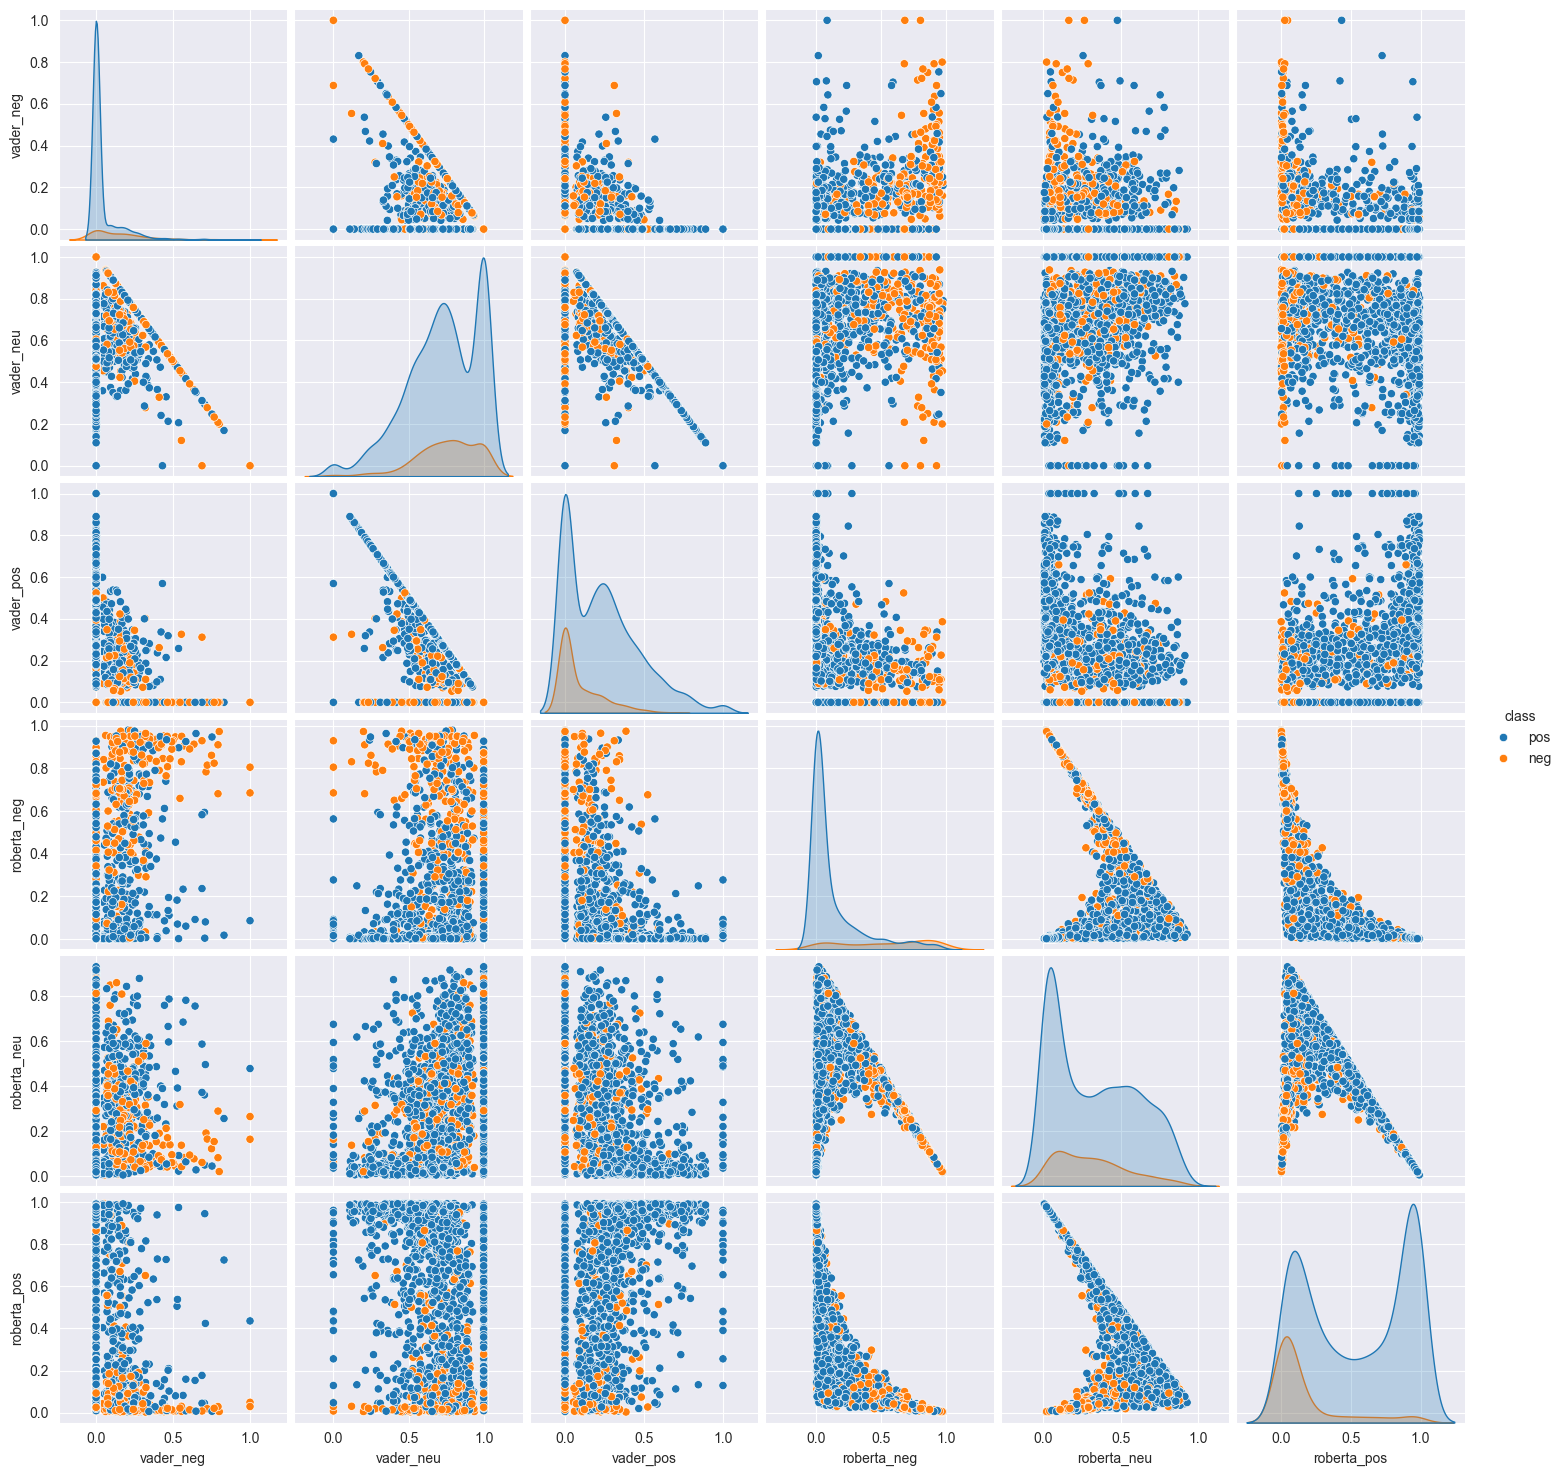

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(results_df, vars=['vader_neg', 'vader_neu', 'vader_pos', 'roberta_neg', 'roberta_neu', 'roberta_pos'], hue='class', palette='tab10')
plt.show()

In [56]:
results_df.query('`class` == "neg"').sort_values('roberta_pos', ascending=False)['text'].head(10)

608     ??? Happy Birthday to you, Happy Birthday to y...
363     I love, love, love the use of color and amazin...
1587    Awww  Hope the meds kick in! Have a blast (I k...
557     Me too!  It was a great ep.  Am so glad it's b...
374     I hope you have an awesome first day!! I'm gon...
283              Happy new yrs everyone. ang lungkot koo 
1101    lol hahaha. Nah. Converse is cool I had a nice...
832     church x-mas pageant today!  I forward to this...
1921    Thanks, saw them a few times, most memorable w...
1025    that's so sweet what you said about your daugh...
Name: text, dtype: object

In [57]:
results_df.query('`class` == "neg"').sort_values('vader_pos', ascending=False)['text'].head(10)

1313                         Hope you feel better soon.. 
1218                                   I should hope so. 
363     I love, love, love the use of color and amazin...
1978                            yeah, I got confused...  
727     I was hoping that Chrome would allow me to boo...
1101    lol hahaha. Nah. Converse is cool I had a nice...
860          LOL, we don't even get 2GB drives as prizes 
1490                                hey I need your help 
1131    Ack! I'm cringing just reading that. Hope your...
373                          I really wish it were that. 
Name: text, dtype: object

In [58]:
results_df.query('`class` == "pos"').sort_values('roberta_neg', ascending=False)['text'].head(10)

460     i DO hate the use of the X for christmas....  ...
799     This rain is fucking annoying and I found my w...
1720                                     p.s. i hate you 
1698    must be a my people kinda thing.  My brain is ...
1097                 can I have some?  pizza in NC sucks 
510          no one is exempt from that. It's just gross 
1729                             you dirty dirty person! 
414     Dude... It's a CARTOON!  Sheesh!  Bart would b...
1972    I'm jealous. I miss Hawaii, and Kaneohe Bay SO...
280                                     LOl you are bad  
Name: text, dtype: object

In [59]:
results_df.query('`class` == "pos"').sort_values('vader_neg', ascending=False)['text'].head(10)

1379                 no problem 
1566            no problem baby 
1729    you dirty dirty person! 
69       No problem. Vent away. 
744     Crazy cool...neighbors. 
493           but a coolio fail 
880                    No way...
1801                   no probz 
1720            p.s. i hate you 
2088          od pocetka 1 po 1 
Name: text, dtype: object

## TRANSFORMERS

In [60]:
from transformers import pipeline
sentiment_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
C:\Users\ferna\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ferna\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to act